# Mise en jambe - Détection de navires sur images satellites

Ce notebook répond aux questions du README `Sujet5/MiseEnJambe/README.md` avec une approche simple.

Objectif : comprendre la structure des métadonnées et des annotations avant de parler modèle.

Point important : les URLs d'images pointent vers `example.com`. On traite donc ici les métadonnées et annotations fournies. Pour la visualisation, le notebook prévoit un affichage sur image locale si elle existe, sinon sur une image blanche de démonstration.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

candidate_dirs = [Path('.'), Path('Sujet5/MiseEnJambe')]
DATA_DIR = next(path for path in candidate_dirs if (path / 'images_metadata_small.csv').exists())
METADATA_PATH = DATA_DIR / 'images_metadata_small.csv'
ANNOTATIONS_PATH = DATA_DIR / 'annotations_small.json'

images = pd.read_csv(METADATA_PATH)
with open(ANNOTATIONS_PATH, 'r', encoding='utf-8') as f:
    coco = json.load(f)

images.head()

,image_id,file_name,date,time,zone_id,zone_name,coordinates,country,resolution,source,num_ships,ship_types,cloud_cover,url
0,IMG-000,satellite_000.jpg,2026-05-01,16:58:29,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,1m,Sentinel-2,3,"Chalutier, Navire de guerre, Destroyer",24.2,https://example.com/satellite_images/satellite...
1,IMG-001,satellite_001.jpg,2026-05-02,10:32:33,ZONE-007,Mer de Chine Méridionale,"15.0,110.0",International,1m,Maxar,1,Chalutier,3.6,https://example.com/satellite_images/satellite...
2,IMG-002,satellite_002.jpg,2026-05-03,10:06:54,ZONE-001,Port militaire de Toulon,"43.12,5.9",France,10m,Landsat-8,3,"Porte-avions, Chalutier, Pétrolier",9.7,https://example.com/satellite_images/satellite...
3,IMG-003,satellite_003.jpg,2026-05-04,19:05:21,ZONE-004,Détroit de Malacca,"3.0,101.0",International,1m,PlanetScope,1,Pétrolier,4.6,https://example.com/satellite_images/satellite...
4,IMG-004,satellite_004.jpg,2026-05-05,11:56:44,ZONE-009,Base navale de Yokosuka,"35.4,139.7",Japan,10m,Sentinel-2,2,"Frégate, Cargo",20.9,https://example.com/satellite_images/satellite...


## 1. Structure des métadonnées

On commence par regarder les colonnes disponibles et le nombre d'images qui contiennent plus d'un navire.

In [2]:
print('Champs disponibles :')
for col in images.columns:
    print('-', col)

nb_plusieurs_navires = (images['num_ships'] > 1).sum()
print(f"\nNombre d'images contenant plus de 1 navire : {nb_plusieurs_navires} / {len(images)}")

Champs disponibles :
- image_id
- file_name
- date
- time
- zone_id
- zone_name
- coordinates
- country
- resolution
- source
- num_ships
- ship_types
- cloud_cover
- url

Nombre d'images contenant plus de 1 navire : 16 / 20


Réponse attendue : le fichier contient 20 images. Les champs utiles pour un MVP sont l'identifiant image, le nom du fichier, la date, la zone, les coordonnées, la résolution, la source, le nombre de navires, les types déclarés et la couverture nuageuse.

## 2. Analyse des zones géographiques

On identifie les zones les plus représentées. Pour les zones à risque élevé, le petit fichier ne contient pas de colonne `risk_level`, donc on utilise une liste de zones sensibles citées dans le sujet.

In [3]:
top_zones = images['zone_name'].value_counts().head(3)
print('Top 3 des zones les plus représentées :')
display(top_zones.to_frame('nombre_images'))

zones_sensibles = ['Détroit de Malacca', 'Golfe Persique', "Détroit d'Ormuz", 'Canal de Suez', 'Mer de Chine Méridionale']
images_zones_sensibles = images[images['zone_name'].isin(zones_sensibles)]
print(f"Images provenant de zones considérées sensibles : {len(images_zones_sensibles)} / {len(images)}")
display(images_zones_sensibles[['image_id', 'zone_name', 'country', 'num_ships', 'ship_types']])

Top 3 des zones les plus représentées :


,nombre_images
zone_name,
Mer de Chine Méridionale,5
Base navale de Norfolk,3
Canal de Suez,3


Images provenant de zones considérées sensibles : 10 / 20


,image_id,zone_name,country,num_ships,ship_types
1,IMG-001,Mer de Chine Méridionale,International,1,Chalutier
3,IMG-003,Détroit de Malacca,International,1,Pétrolier
5,IMG-005,Canal de Suez,Egypt,2,"Chalutier, Cargo"
6,IMG-006,Canal de Suez,Egypt,2,"Destroyer, Pétrolier"
9,IMG-009,Détroit de Malacca,International,3,"Frégate, Porte-avions, Destroyer"
12,IMG-012,Mer de Chine Méridionale,International,3,"Navire de guerre, Destroyer, Cargo"
13,IMG-013,Mer de Chine Méridionale,International,3,"Destroyer, Frégate, Navire civil"
16,IMG-016,Mer de Chine Méridionale,International,2,"Chalutier, Pétrolier"
17,IMG-017,Canal de Suez,Egypt,2,"Navire civil, Porte-avions"
19,IMG-019,Mer de Chine Méridionale,International,3,"Navire de guerre, Frégate, Destroyer"


## 3. Résolution et qualité des images

La résolution donne une première idée de la capacité à détecter des objets fins. La couverture nuageuse aide à anticiper les images difficiles.

In [4]:
resolution_freq = images['resolution'].value_counts()
resolution_mode = images['resolution'].mode().iloc[0]
cloud_avg = images['cloud_cover'].mean()

print('Répartition des résolutions :')
display(resolution_freq.to_frame('nombre_images'))
print(f"Résolution la plus fréquente : {resolution_mode}")
print(f"Couverture nuageuse moyenne : {cloud_avg:.2f}%")

Répartition des résolutions :


,nombre_images
resolution,
10m,10
1m,5
5m,5


Résolution la plus fréquente : 10m
Couverture nuageuse moyenne : 12.46%


## 4. Structure des annotations COCO

Le format COCO sépare les images, les annotations et les catégories. Chaque annotation correspond ici à une bounding box de navire.

In [5]:
categories = pd.DataFrame(coco['categories'])
annotations = pd.DataFrame(coco['annotations'])
image_index = pd.DataFrame(coco['images'])
category_map = dict(zip(categories['id'], categories['name']))
annotations['category_name'] = annotations['category_id'].map(category_map)

print(f"Nombre de catégories : {len(categories)}")
print(f"Nombre total d'annotations / bounding boxes : {len(annotations)}")
display(categories)

Nombre de catégories : 8
Nombre total d'annotations / bounding boxes : 43


,id,name,supercategory
0,1,Navire civil,ship
1,2,Navire de guerre,ship
2,3,Frégate,ship
3,4,Destroyer,ship
4,5,Porte-avions,ship
5,6,Pétrolier,ship
6,7,Cargo,ship
7,8,Chalutier,ship


## 5. Répartition des types de navires

On compte les annotations par type. Pour la mise en jambe, le README définit comme militaires : frégates, destroyers et porte-avions.

In [6]:
type_counts = annotations['category_name'].value_counts()
display(type_counts.to_frame('nombre_annotations'))

military_classes_readme = ['Frégate', 'Destroyer', 'Porte-avions']
nb_militaires = annotations['category_name'].isin(military_classes_readme).sum()
most_common_type = type_counts.index[0]

print(f"Type de navire le plus fréquent : {most_common_type}")
print(f"Nombre de navires militaires selon la définition du README : {nb_militaires}")

,nombre_annotations
category_name,
Chalutier,9
Frégate,8
Destroyer,7
Pétrolier,6
Porte-avions,4
Navire de guerre,3
Cargo,3
Navire civil,3


Type de navire le plus fréquent : Chalutier
Nombre de navires militaires selon la définition du README : 19


## 6. Taille moyenne des bounding boxes

Dans ce fichier, les bounding boxes sont normalisées : `x`, `y`, `width`, `height` sont entre 0 et 1. L'aire en pourcentage de l'image vaut donc `width * height * 100`.

In [7]:
bbox = pd.DataFrame(annotations['bbox'].tolist(), columns=['x', 'y', 'width', 'height'])
annotations_bbox = pd.concat([annotations.drop(columns=['bbox']), bbox], axis=1)
annotations_bbox['bbox_area_pct'] = annotations_bbox['width'] * annotations_bbox['height'] * 100

avg_bbox_area = annotations_bbox['bbox_area_pct'].mean()
area_by_type = annotations_bbox.groupby('category_name')['bbox_area_pct'].mean().sort_values(ascending=False)

print(f"Taille moyenne des bounding boxes : {avg_bbox_area:.2f}% de l'image")
print(f"Type avec les plus grandes bounding boxes en moyenne : {area_by_type.index[0]}")
display(area_by_type.to_frame('surface_moyenne_pct'))

Taille moyenne des bounding boxes : 1.50% de l'image
Type avec les plus grandes bounding boxes en moyenne : Frégate


,surface_moyenne_pct
category_name,
Frégate,1.652552
Chalutier,1.635553
Navire civil,1.593666
Porte-avions,1.575953
Destroyer,1.487410
Navire de guerre,1.304519
Pétrolier,1.291383
Cargo,1.181539


## 7. Affichage d'une image et de ses annotations

Comme les images ne sont pas fournies localement, la cellule ci-dessous fonctionne de deux façons :

- si un fichier `images/satellite_000.jpg` existe, il l'utilise ;
- sinon, il dessine les bounding boxes sur une image blanche, ce qui permet quand même de vérifier la structure des annotations.

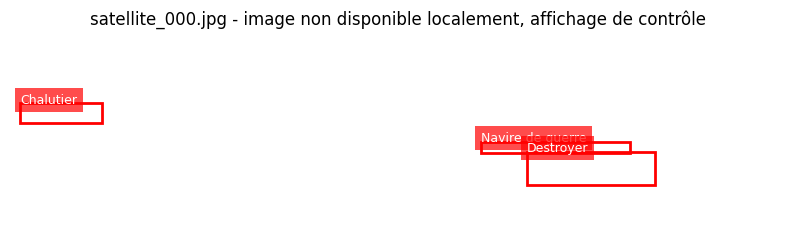

In [8]:
def show_image_annotations(file_name='satellite_000.jpg'):
    img_row = image_index[image_index['file_name'] == file_name].iloc[0]
    image_id = img_row['id']
    width = int(img_row['width'])
    height = int(img_row['height'])

    local_image = DATA_DIR / 'images' / file_name
    fig, ax = plt.subplots(figsize=(10, 6))

    if local_image.exists():
        img = plt.imread(local_image)
        ax.imshow(img)
    else:
        ax.imshow([[1]], extent=[0, width, height, 0], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{file_name} - image non disponible localement, affichage de contrôle')

    ann_img = annotations_bbox[annotations_bbox['image_id'] == image_id]
    for _, row in ann_img.iterrows():
        x = row['x'] * width
        y = row['y'] * height
        w = row['width'] * width
        h = row['height'] * height
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
        ax.text(x, y, row['category_name'], color='white', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none'))

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.axis('off')
    plt.show()

show_image_annotations('satellite_000.jpg')

## 8. Détection manuelle

Sans les vraies images, on ne peut pas compter visuellement les navires. La table ci-dessous prépare le travail manuel : dès que les images sont récupérées, il suffit de remplir `manual_count` puis de comparer avec `num_ships`.

In [9]:
manual_check = images[['image_id', 'file_name', 'zone_name', 'num_ships', 'ship_types']].head(5).copy()
manual_check['manual_count'] = None
manual_check['difference_manual_vs_metadata'] = None
manual_check

,image_id,file_name,zone_name,num_ships,ship_types,manual_count,difference_manual_vs_metadata
0,IMG-000,satellite_000.jpg,Base navale de Norfolk,3,"Chalutier, Navire de guerre, Destroyer",None,None
1,IMG-001,satellite_001.jpg,Mer de Chine Méridionale,1,Chalutier,None,None
2,IMG-002,satellite_002.jpg,Port militaire de Toulon,3,"Porte-avions, Chalutier, Pétrolier",None,None
3,IMG-003,satellite_003.jpg,Détroit de Malacca,1,Pétrolier,None,None
4,IMG-004,satellite_004.jpg,Base navale de Yokosuka,2,"Frégate, Cargo",None,None


Conclusion provisoire : cette étape reste à faire à la main après récupération des images. Elle est utile pour repérer des écarts entre ce qui est annoté et ce qu'un humain voit réellement.

## 9. Limites possibles des annotations

Problèmes possibles :

- bounding boxes un peu trop larges ou trop serrées ;
- navire visible mais non annoté ;
- confusion entre navire civil et militaire ;
- petits navires difficiles à repérer en basse résolution ;
- effet de la couverture nuageuse, des ombres, du sillage et des infrastructures portuaires ;
- catégories parfois trop proches visuellement, par exemple frégate, destroyer et croiseur.

Améliorations possibles :

- double annotation humaine sur un échantillon ;
- validation par un référent métier ;
- ajout d'un score de confiance par annotation ;
- règles de cohérence sur la taille des bounding boxes ;
- comparaison entre plusieurs sources d'images pour une même zone.

## 10. Améliorations pour la détection automatique

Champs utiles à ajouter aux métadonnées :

- angle de prise de vue ;
- résolution exacte en mètres par pixel ;
- capteur utilisé ;
- niveau de zoom ;
- heure locale ;
- état météo ;
- type de zone : port, mer ouverte, détroit, base navale ;
- présence d'infrastructures portuaires ;
- niveau de risque de la zone.

Automatisation possible des bounding boxes :

- utiliser un modèle pré-entraîné type YOLO ou Faster R-CNN ;
- générer des prédictions sur les images ;
- faire valider seulement les prédictions incertaines par un humain ;
- enrichir progressivement le dataset avec ces corrections ;
- garder un historique des erreurs pour améliorer le modèle.

## Synthèse mise en jambe

Ce petit dataset est suffisant pour comprendre la logique du problème : métadonnées image, annotations COCO, catégories de navires et premières limites.

La prochaine étape data n'est pas encore l'entraînement. C'est d'abord la récupération d'images réelles correspondant aux fichiers ou à des sources ouvertes exploitables.